# 02. Diabetes Health Indicators: Model Training and Evaluation

**Objective:** To build, train, and evaluate machine learning pipelines using the preprocessed BRFSS dataset, with a strong focus on handling class imbalance using appropriate metrics (F1-Score, Recall).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the preprocessed and split datasets
X_train = pd.read_csv('datasets/X_train.csv')
X_test = pd.read_csv('datasets/X_test.csv')
y_train = pd.read_csv('datasets/y_train.csv').squeeze() # squeeze() converts DataFrame to Series
y_test = pd.read_csv('datasets/y_test.csv').squeeze()

print('Data successfully loaded')
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')

Data successfully loaded
X_train shape: (183824, 21)
y_train shape: (183824,)


## 1. Preprocessing Pipeline Setup
Before feeding the data into a machine learning model, we must preprocess our features based on their inherent data types and distributions.

1. **Log Transformation for Skewed Data (`BMI`):**
   Our EDA revealed that `BMI` is highly right-skewed with extreme values (>70). To prevent these outliers from disproportionately influencing the Logistic Regression decision boundary, we apply a Log Transformation (`np.log1p`) followed by `StandardScaler`.
2. **Standard Scaling for Ordinal Variables (`Age`, `Income`, etc.):**
   Variables like `Age` and `Income` are ordinal categories. We treat them as continuous and apply `StandardScaler`.
3. **Passthrough for Binary Variables (`Sex`, `HighBP`, etc.):**
   These are already encoded as 0 or 1, requiring no further transformation.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline

# Grouping features based on their types
skewed_features = ['BMI']
num_ord_features = ['GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
binary_features = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 
                   'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

# Custom pipeline for skewed data (Log transform -> Standard Scale)
# We use np.log1p (log(1+x)) which is mathematically safer
log_scale_transformer = Pipeline(steps=[
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

# Building the final preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('skewed', log_scale_transformer, skewed_features),
        ('num_ord', StandardScaler(), num_ord_features),
        ('binary', 'passthrough', binary_features)
    ])

print('Preprocessing pipeline successfully configured.')

Preprocessing pipeline successfully configured.


## 2. Baseline Model Development: Logistic Regression

We establish Logistic Regression as our baseline model due to its interpretability and efficiency in medical risk scoring. 

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Construct the pipeline
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Train and Predict
log_reg_pipeline.fit(X_train, y_train)
y_pred_log_reg = log_reg_pipeline.predict(X_test)

# Statistical performance metrics
print('Classification Report (Logistic Regression)\n')
print(classification_report(y_test, y_pred_log_reg, zero_division=0))

Classification Report (Logistic Regression)

              precision    recall  f1-score   support

         0.0       0.85      0.97      0.91     38012
         1.0       0.00      0.00      0.00       926
         2.0       0.55      0.18      0.27      7019

    accuracy                           0.83     45957
   macro avg       0.47      0.39      0.39     45957
weighted avg       0.79      0.83      0.79     45957



**Interpretation: The Accuracy Paradox in Action**

1. **High Overall Accuracy vs. Clinical Failure:** The model achieved an overall accuracy of 83%. However, this metric is highly misleading. The model achieved this simply by heavily biasing its predictions toward the majority class (Normal, Class 0.0), which has a 97% recall.
2. **Failure on Minority Classes:** The model completely failed to identify Prediabetes (Recall: 0.00) and missed the vast majority of actual Diabetes cases (Recall: 0.18). The model did not predict a single instance of Prediabetes, rendering it clinically unusable.
3. **Conclusion:** This baseline perfectly demonstrates that an unweighted model is heavily penalized by the dataset's skewness. To make the model clinically viable, we must apply imbalance mitigation techniques, starting with `class_weight='balanced'`.

## 3. Mitigating Imbalance: Balanced Logistic Regression
Having observed the Accuracy Paradox in the vanilla model, we now introduce the `class_weight='balanced'` parameter. This mathematically forces the algorithm to pay more attention to the minority classes (Prediabetes and Diabetes) by penalizing misclassifications inversely proportional to their frequencies.

In [9]:
# Construct the balanced pipeline
balanced_log_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# Train and Predict
balanced_log_pipeline.fit(X_train, y_train)
y_pred_balanced = balanced_log_pipeline.predict(X_test)

# Print results
print('Classification Report (Balanced Logistic Regression)\n')
print(classification_report(y_test, y_pred_balanced))

Classification Report (Balanced Logistic Regression)

              precision    recall  f1-score   support

         0.0       0.94      0.64      0.77     38012
         1.0       0.03      0.31      0.06       926
         2.0       0.37      0.59      0.46      7019

    accuracy                           0.63     45957
   macro avg       0.45      0.52      0.43     45957
weighted avg       0.84      0.63      0.70     45957



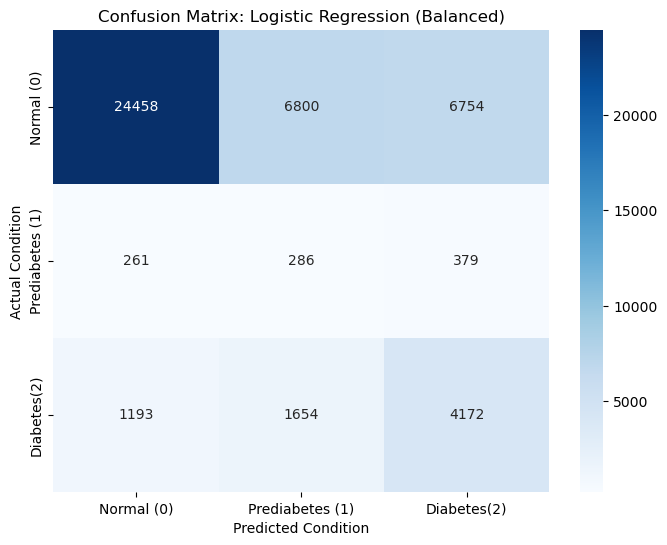

In [10]:
from sklearn.metrics import confusion_matrix

# Visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_balanced)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Prediabetes (1)', 'Diabetes(2)'],
            yticklabels=['Normal (0)', 'Prediabetes (1)', 'Diabetes(2)'])
plt.title('Confusion Matrix: Logistic Regression (Balanced)')
plt.ylabel('Actual Condition')
plt.xlabel('Predicted Condition')
plt.show()

## 4. Baseline Evaluation and Error Analysis

Comparing the unweighted and balanced Logistic Regression models reveals the fundamental limitations of using linear algorithms for this specific medical dataset.

**1. The Imbalance Trade-off**
The unweighted model suffered from the Accuracy Paradox by entirely ignoring the minority classes. Applying the `class_weight='balanced'` parameter successfully forced the model to recognize Prediabetes (Class 1.0) and Diabetes (Class 2.0). However, this correction overcompensated. By aggressively trying not to miss Class 1.0, the model generated a massive number of False Positives, which collapsed the Precision to an unusable 0.03.

**2. The Linearity Bottleneck**
Logistic regression relies strictly on drawing linear decision boundaries. Clinically, 'Prediabetes' is a highly ambiguous gray area that heavily overlaps with both healthy and diabetic patient profiles. A simple linear combination of general health indicators is mathematically insufficient to isolate this subtle transition state.

**Strategic Pivot: Random Forest Classifier**
To overcome these linear constraints and successfully capture complex feature interactions, we must transition to a tree-based ensemble approach. We will now implement a Random Forest model.

## 5. Advanced Modeling: Balanced Random Forest
Having established that linear boundaries are insufficient, we now deploy a Random Forest Classifier. This tree-based ensemble method is natively equipped to handle non-linear relationships and complex feature interactions without requiring explicit mathematical transformations.

**Key Hyperparameter Configurations:**
* **`class_weight='balanced'`:** We carry over this essential strategy to aggressively penalize the misclassification of the minority classes (Prediabetes and Diabetes).
* **`max_depth=10'`:** Given the extreme class imbalance, decision trees are highly prone to overfitting the minority classes by creating overly specific, deep branches. We restrict the maximum depth to 10 to act as a strong regularization mechanism, forcing the model to learn generalized patterns.
* **`n_jobs=-1'`:** Utilizes all available CPU cores to optimize training speed for this computationally intensive ensemble.

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Construct the pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100,
                                          max_depth=10,
                                          class_weight='balanced',
                                          random_state=42,
                                          n_jobs=-1))
])

# Train and Predict
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print('Classification Report (Random Forest)\n')
print(classification_report(y_test, y_pred_rf))

Classification Report (Random Forest)

              precision    recall  f1-score   support

         0.0       0.94      0.68      0.79     38012
         1.0       0.03      0.13      0.05       926
         2.0       0.34      0.69      0.46      7019

    accuracy                           0.67     45957
   macro avg       0.44      0.50      0.43     45957
weighted avg       0.83      0.67      0.72     45957



### 6. Random Forest Evaluation and Strategic Pivot to Binary Classification

**Interpretation: Random Forest Performance**
1. **Significant Gain in Diabetes Recall:** The tree-based ensemble successfully captured non-linear relationships, pushing the Recall for Diabetes (Class 2.0) up to 0.69 (compared to 0.59 in the linear model). This is a substantial improvement for medical screening purposes.
2. **The Prediabetes Bottleneck:** Despite the algorithmic upgrade, Prediabetes (Class 1.0) remains completely indistinguishable (Recall: 0.13, Precision: 0.03). This mathematically proves that the available features in the BRFSS dataset lack the clinical specificity required to isolate this subtle transition phase.

**Final Strategic Pivot: Target Binarization**
In real-world preventative healthcare, both Prediabetes and Diabetes require medical intervention. Therefore, differentiating between the two is less critical than identifying if a patient is simply "At Risk." We will completely redefine our machine learning problem by merging Class 1.0 and Class 2.0 into a single positive class (`1.0`: At Risk), transforming this multi-class challenge into a clean Binary Classification problem.

In [22]:
# Merge Prediabetes (1.0) and Diabetes (2.0) into '1.0'
y_train_binary = y_train.replace({2.0: 1.0})
y_test_binary = y_test.replace({2.0: 1.0})

print('Target variable successfully binarized.')
print('New Train Distribution:\n', y_train_binary.value_counts(normalize=True).round(3))

Target variable successfully binarized.
New Train Distribution:
 Diabetes_012
0.0    0.827
1.0    0.173
Name: proportion, dtype: float64


In [26]:
# Re-train the Random Forest Pipeline on the binary target
rf_pipeline.fit(X_train, y_train_binary)
# Predict and evaluate
y_pred_binary = rf_pipeline.predict(X_test)

print('Classification Report (Binary Random Forest)\n')
print(classification_report(y_test_binary, y_pred_binary))

Classification Report (Binary Random Forest)

              precision    recall  f1-score   support

         0.0       0.93      0.71      0.81     38012
         1.0       0.36      0.76      0.48      7945

    accuracy                           0.72     45957
   macro avg       0.64      0.74      0.65     45957
weighted avg       0.83      0.72      0.75     45957



### 7. Binary Model Evaluation: ROC-AUC Analysis

**Interpretation of Binary Results:**
By binarizing the target, the model successfully increased the Recall for the 'At Risk' group to 0.76. While Precision remains relatively low (0.36), this trade-off is mathematically acceptable and clinically preferred in preliminary medical screenings, where capturing potential patients is the absolute priority.

**ROC-AUC Curve:**
To objectively evaluate the binary classifier's performance across all classification thresholds, independent of specific class weights, we plot the Receiver Operating Characteristic (ROC) curve and calculate the Area Under the Curve (AUC).

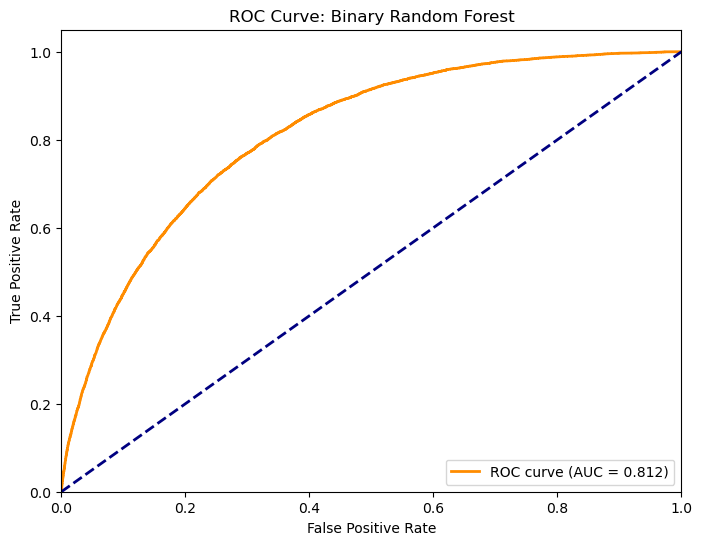

In [39]:
from sklearn.metrics import roc_curve, auc

# Probabilities for the positive class (1.0)
y_pred_proba = rf_pipeline.predict_proba(X_test)[:, 1]

# Compute ROC metrics
fpr, tpr, thresholds = roc_curve(y_test_binary, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Visualize ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Binary Random Forest')
plt.legend(loc='lower right')
plt.show()

**Interpretation of ROC-AUC:**
An AUC score of 0.812 indicates good discriminative ability. 
It means there is an 81.2% probability that the model will assign a higher predicted probability to a randomly chosen 'At Risk' patient than to a randomly chosen 'Normal' patient. 
This suggests a solid baseline performance for the binary classifier.

**Rationale for Hyperparameter Tuning:**
While an AUC of 0.812 is clinically viable for initial screening, preventing metabolic disease requires maximizing predictive power. We will now deploy `RandomizedSearchCV` to fine-tune the tree architecture (e.g., depth, split criteria) and extract the absolute maximum performance from this algorithm.

### 8. Hyperparameter Tuning: Efficient Shortcut via RandomizedSearchCV

While the baseline Random Forest demonstrates solid Recall, we must optimize its hyperparameters to maximize the AUC score. Given the large dataset size (>250k records), an exhaustive `GridSearchCV` is computationally prohibitive. Therefore, we utilize `RandomizedSearchCV` as an efficient shortcut to sample the hyperparameter space and locate near-optimal configurations with minimal computational cost.